# **Aprendizado de Máquina** <BR> **Aula 06** - Classificador *SVM* e ajuste de hiperparâmetros

# **Exercício 1**. Classificação por *SVM* no *dataset Iris*

## **1)** Importação de bibliotecas e classes

In [31]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# Bibliotecas específicas de Machine Learning
from sklearn.svm import SVC                           # Classificador [por] SVM

from sklearn.preprocessing import StandardScaler      # Padronização de atributos
from sklearn.model_selection import train_test_split  # Divisão de dados para validação cruzada hold-out
from sklearn.model_selection import cross_val_score   # Validação cruzada k-folds

from sklearn.metrics import accuracy_score, classification_report   # Métricas de qualidade
from sklearn.metrics import ConfusionMatrixDisplay    # Visualização "gráfica" da matriz de confusão

## **2)** Leitura de dados e exploração inicial

In [33]:
# Leitura do arquivo de dados e exibição do DataFrame
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados!
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/A05EXEMPLO1_iris.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


### **2.1)** Características gerais

In [34]:
# Contagem de classes da resposta/target
df['species'].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


### **2.2)** Gráficos

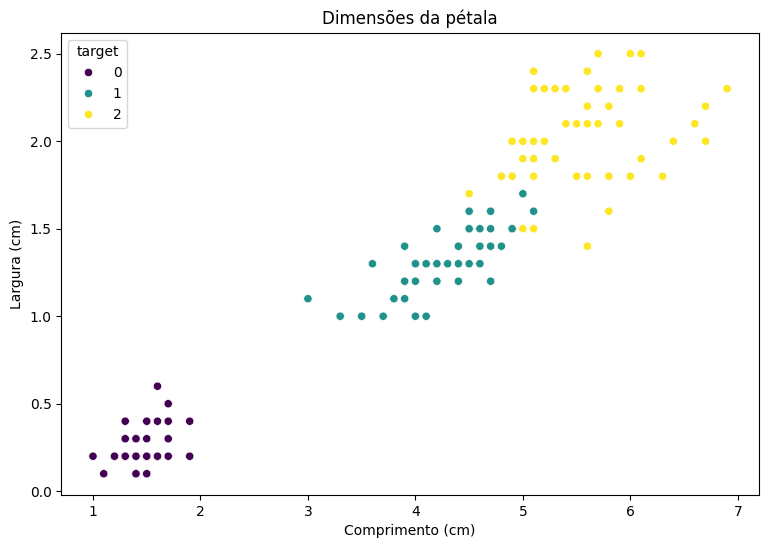

In [35]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                palette = 'viridis', hue = 'target')
plt.show()

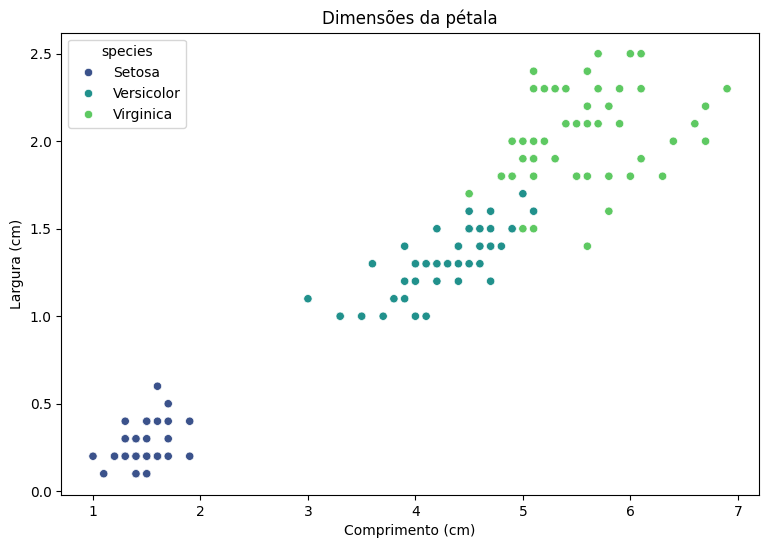

In [36]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                palette = 'viridis', hue = 'species')
plt.show()

## **3)** Seleção e pré-processamento de variáveis

In [37]:
# Recordando os nomes das colunas do DataFrame
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [38]:
X = df.drop(columns = ['target','species'])   # Atributos: 4 dimensões das flores
y = df['species']                             # Reposta: espécie. Opção: df['target']

In [39]:
# Pré-processamento 1: divisão em dados de treino (80%) e teste (20%)
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução da função de divisão
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8,
                                                        random_state = 42,
                                                        stratify = y)

In [40]:
# Pré-processamento 2: PADRONIZAÇÃO dos atributos (treino e
# teste) segundo a média e desvio padrão DO CONJUNTO DE TREINO

# Criação de instância e treinamento de um objeto "escalonador"
escalonador = StandardScaler()
escalonador.fit(X_treino)

# Padronização dos dados de treino e de teste
X_treino_Padr = escalonador.transform(X_treino)
X_teste_Padr = escalonador.transform(X_teste)

# Conversão dos conjuntos padronizados em DataFrames
X_treino_Padr = pd.DataFrame(data = X_treino_Padr,columns = X_treino.columns)
X_teste_Padr = pd.DataFrame(data = X_teste_Padr,columns = X_treino.columns)

## **4)** Treinamento do classificador [por] *SVM*

In [41]:
# Criação de instância e treinamento do classificador [por] SVM
# COMPLETAR. NOME SUGERIDO: 'clf_SVM'
clf_SVM = SVC()
clf_SVM.fit(X_treino_Padr,y_treino)


SVC()

## **5)** Validação cruzada *hold-out*

In [42]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_SVM.predict(X_teste_Padr)

# Cálculo da acurácia
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.9666666666666667


In [43]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

      Setosa     1.0000    1.0000    1.0000        10
  Versicolor     1.0000    0.9000    0.9474        10
   Virginica     0.9091    1.0000    0.9524        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



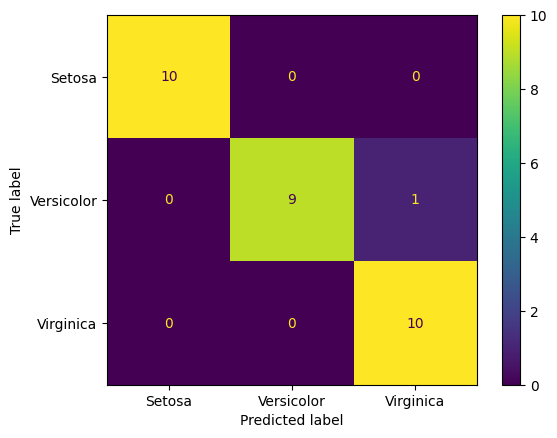

In [44]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.show()

## **6)** Validação cruzada *k-folds*

In [45]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_SVM,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [1.         0.93333333 1.         0.93333333 1.         0.93333333
 0.86666667 1.         1.         1.        ]

Acurácia média = 0.9666666666666666
Coeficiente de variação (%) = 4.626347539654737


---
**Fim do Exercício 1 da Aula 06**

# **Exercício 2**. <u>Busca em grade</u> para o classificador *SVM*

In [ ]:
# Importação da biblioteca necessária para a busca em grade (Grid Search)
from sklearn.model_selection import GridSearchCV

In [51]:
# Definição do dicionário de valores da grade (hiperparâmetros 'C' e 'gamma')
# COMPLETAR
GradeHP = {'C': [0.001, 0.1, 1, 10, 100, 1000],
           'gamma': [0.001, 0.1, 1, 10, 100, 1000]}

In [52]:
# Definição do classificador usado na busca, SE NECESSÁRIO
# clf_SVM = SVC()

# Criação de instância da grade de busca + treinamentos e testes (com validação cruzada)
GradeBusca = GridSearchCV(clf_SVM,param_grid = GradeHP,cv = 10,scoring = 'accuracy')
GradeBusca.fit(X_Padr,y)


GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [0.001, 0.1, 1, 10, 100, 1000],
                         'gamma': [0.001, 0.1, 1, 10, 100, 1000]},
             scoring='accuracy')

In [53]:
# Exibição da melhor solução obtida (não é "ótima"!)
print("Melhor solução:",GradeBusca.best_estimator_)

print("")   # "Imprime" uma linha em branco
print("Melhor valor de 'C' =",GradeBusca.best_estimator_.C)
print("Melhor valor de 'gamma' =",GradeBusca.best_estimator_.gamma)

Melhor solução: SVC(C=1, gamma=0.1)

Melhor valor de 'C' = 1
Melhor valor de 'gamma' = 0.1


In [54]:
# Detalhes da busca: dicionário de resultados convertido em DataFrame
resultados = GradeBusca.cv_results_
df_resultados = pd.DataFrame(data = resultados)
display(df_resultados)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005121,0.003479,0.002217,0.000129,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",0.733333,0.866667,0.933333,0.866667,0.800000,0.866667,0.866667,0.866667,0.933333,0.866667,0.860000,0.055377,19
1,0.004009,0.000160,0.002368,0.000378,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.733333,0.866667,0.933333,0.866667,0.866667,0.800000,0.866667,0.866667,0.933333,0.866667,0.860000,0.055377,19
2,0.004416,0.000910,0.002441,0.000501,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.866667,0.933333,1.000000,0.866667,0.933333,0.933333,0.866667,1.000000,0.933333,1.000000,0.933333,0.051640,12
3,0.003926,0.000157,0.002211,0.000174,0.001,10.000,"{'C': 0.001, 'gamma': 10}",0.800000,0.733333,0.733333,0.733333,0.733333,0.866667,0.733333,0.800000,0.666667,1.000000,0.780000,0.089691,23
4,0.004313,0.000104,0.002359,0.000093,0.001,100.000,"{'C': 0.001, 'gamma': 100}",0.600000,0.466667,0.400000,0.400000,0.333333,0.533333,0.333333,0.400000,0.533333,0.466667,0.446667,0.084591,29
5,0.004077,0.000172,0.002195,0.000226,0.001,1000.000,"{'C': 0.001, 'gamma': 1000}",0.400000,0.400000,0.400000,0.333333,0.333333,0.333333,0.333333,0.400000,0.400000,0.400000,0.373333,0.032660,34
6,0.002361,0.000404,0.001346,0.000249,0.100,0.001,"{'C': 0.1, 'gamma': 0.001}",0.733333,0.866667,0.933333,0.866667,0.800000,0.866667,0.866667,0.866667,0.933333,0.866667,0.860000,0.055377,19
7,0.001915,0.000110,0.001207,0.000029,0.100,0.100,"{'C': 0.1, 'gamma': 0.1}",0.800000,0.866667,0.933333,0.933333,0.866667,0.866667,0.866667,0.933333,0.933333,1.000000,0.900000,0.053748,17
8,0.002064,0.000136,0.001277,0.000251,0.100,1.000,"{'C': 0.1, 'gamma': 1}",0.933333,0.933333,1.000000,0.933333,0.933333,0.933333,0.866667,1.000000,0.933333,1.000000,0.946667,0.040000,10
9,0.002232,0.000116,0.001239,0.000073,0.100,10.000,"{'C': 0.1, 'gamma': 10}",0.800000,0.733333,0.733333,0.733333,0.733333,0.866667,0.733333,0.800000,0.666667,1.000000,0.780000,0.089691,23


---
**Fim do Exercício 2 da Aula 06**